# 01. Drift detection — the Peshawar grid upgrade story

This notebook tells one story end-to-end: a realistic intervention (the
Peshawar utility installs grid stabilizers, reducing outage frequency)
silently breaks the trained model, and drift monitoring catches it.

The deeper finding is the **counterintuitive one**: the model's *risk scores
go up* for Peshawar even though the *batteries are objectively healthier*.
We explain why, and we explain why retraining alone won't fix it.


In [1]:
import sys, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb

sys.path.insert(0, "..")
sys.path.insert(0, "../src")

OUTPUTS = Path("..") / "outputs"
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True


## Setup: load alarms + model + reference profile

We use the drain predictor (48h horizon, binary classifier) and its
training-time reference profile.


In [2]:
from battery_pdm.monitoring.drift import load_reference_profile, detect_drift
from battery_pdm.common.features import compute_features
from battery_pdm.synth.load_shedding import build_load_shedding_schedule

alarms = pd.read_parquet(OUTPUTS / "alarms.parquet")
sites = pd.read_parquet(OUTPUTS / "site_static.parquet")
schedule = build_load_shedding_schedule(n_months=36, seed=42)

# Subsample to keep this notebook fast
SEED = 42
rng = np.random.default_rng(SEED)
sample = sites["site_id"].sample(100, random_state=SEED).tolist()
alarms = alarms[alarms["site_id"].isin(sample)].reset_index(drop=True)
sites = sites[sites["site_id"].isin(sample)].reset_index(drop=True)
print(f"Working with {len(alarms):,} alarms across {len(sites)} sites")


Working with 43,752 alarms across 100 sites


## Step 1: load the trained model + its reference profile

The reference profile is the **distribution of features at training time** —
this is what drift detection compares against. Critically, this profile must
come from *training data*, not from the first production window (a real bug we
caught in code review and fixed).


In [3]:
model_dir = OUTPUTS / "models" / "drain_predictor_48h"
booster = xgb.Booster()
booster.load_model(str(model_dir / "booster.json"))
meta = json.loads((model_dir / "meta.json").read_text())
ref_profile = load_reference_profile(model_dir / "reference_profile.json")
print(f"Model version: {meta['model_version']}")
print(f"Feature hash:  {meta['feature_hash']}")
print(f"Reference profile: {ref_profile['n_samples']} training samples, "
      f"{len(ref_profile['features'])} features")


Model version: 20260524_174447
Feature hash:  16f0a8788c63b30c
Reference profile: 37931 training samples, 38 features


## Step 2: simulate the Peshawar grid upgrade

At month 24, Peshawar's utility installs grid stabilizers. The effect on the
alarm stream:

- 60% fewer `AC_MAINS_FAIL` events (outages just don't happen as often)
- 40% fewer `RECTIFIER_FAULT` events (cleaner power)
- 30% fewer `BATT_UNDERVOLTAGE` events
- 25% fewer `LOAD_DISCONNECT` events (but batteries are still degraded from
  24 months of heavy cycling, so some still drain)

In real life, this is what a regulatory intervention or infrastructure
investment looks like. In ML terms, it's a **covariate shift** that triggers
**concept drift** because the relationship between features and outcomes changes
non-uniformly.


In [4]:
DRIFT_START_H = 24 * 30 * 24   # month 24 in hours
peshawar_sites = set(sites[sites["region"] == "peshawar"]["site_id"])

mask_post = (alarms["site_id"].isin(peshawar_sites)
             & (alarms["timestamp_h"] >= DRIFT_START_H))
drop_mask = pd.Series(False, index=alarms.index)
for code, prob in [("AC_MAINS_FAIL", 0.60), ("RECTIFIER_FAULT", 0.40),
                    ("BATT_UNDERVOLTAGE", 0.30), ("LOAD_DISCONNECT", 0.25)]:
    m = mask_post & (alarms["alarm_code"] == code)
    drop = rng.random(m.sum()) < prob
    drop_mask.loc[alarms.index[m][drop]] = True

alarms_drifted = alarms[~drop_mask].reset_index(drop=True)
print(f"Dropped {drop_mask.sum():,} of {mask_post.sum():,} post-upgrade Peshawar alarms "
      f"({drop_mask.sum()/mask_post.sum():.0%})")


Dropped 2,146 of 5,500 post-upgrade Peshawar alarms (39%)


## Step 3: score at month 30 (6 months after upgrade)

We compute features for all sites at month 30 against the drifted alarm stream,
then score with the original (pre-upgrade) model. The model has *no idea*
anything has changed.


In [5]:
POST_H = 30 * 30 * 24  # month 30
labels_post = pd.DataFrame({
    "site_id": sites["site_id"].values,
    "ref_time_h": float(POST_H),
})
alarms_post = alarms_drifted[alarms_drifted["timestamp_h"] <= POST_H]

features = compute_features(
    labels=labels_post.rename(columns={"ref_time_h": "mains_fail_h"}),
    groups=["alarm_history", "site_static", "soc_proxy", "load_shedding_schedule"],
    inputs={"alarms": alarms_post, "site_static": sites, "schedule": schedule},
    ref_time_col="mains_fail_h",
).rename(columns={"mains_fail_h": "ref_time_h"})

X = features[meta["feature_cols"]].astype(float).fillna(0.0)
preds = booster.predict(xgb.DMatrix(X))
features["risk_score"] = preds
features["region"] = features["site_id"].map(dict(zip(sites["site_id"], sites["region"])))

print(f"\nMean risk by region (post-upgrade scoring):")
features.groupby("region")["risk_score"].agg(["mean", "min", "max"]).round(3)



Mean risk by region (post-upgrade scoring):


,mean,min,max
region,,,
islamabad,0.006,0.000,0.037
karachi,0.228,0.001,0.633
lahore,0.647,0.008,0.875
peshawar,0.651,0.031,0.848
quetta,0.480,0.020,0.881


## Step 4: the counterintuitive finding

**Peshawar risk scores went *up* after the grid upgrade**, even though batteries
are objectively healthier (fewer outages = less wear).

This is the **silent model decay** we want drift monitoring to catch.

### Why does this happen?

The model's #1 feature by gain is `lvd_count_30d` (load disconnect count in the
last 30 days). After the upgrade:

- `mains_fail_count_30d` dropped from 6.65 → 3.65 ✓ (correctly captures fewer outages)
- `lvd_count_30d` actually *rose* slightly because we dropped only 25% of LVDs
  (worn batteries that *do* see an outage still tend to drain)
- `lvd_count_lifetime` only ever increases — the model sees rising lifetime LVDs
  and increases its risk estimate

The model learned a **downstream symptom** (LVD counts) instead of the **root
cause** (outage frequency × battery health). After the intervention, the
symptom persists for a while even though the cause is improving. The model
can't tell the difference.


## Step 5: run drift detection

PSI (Population Stability Index) compares the post-upgrade feature distributions
against the training-time reference. PSI > 0.25 = significant drift.


In [6]:
drift_report = detect_drift(
    reference_profile=ref_profile,
    current_features=features,
    current_predictions=preds,
    feature_cols=meta["feature_cols"],
)

summary = drift_report["summary"]
print(f"Status:                {summary['status']}")
print(f"Features monitored:    {summary['n_features_monitored']}")
print(f"Significant drift:     {summary['n_significant_drift']}")
print(f"Moderate drift:        {summary['n_moderate_drift']}")
print(f"Retrain recommended:   {summary['retrain_recommended']}")
for r in summary.get("reasons", []):
    print(f"  -> {r}")


Status:                DRIFT_DETECTED
Features monitored:    38
Significant drift:     11
Moderate drift:        10
Retrain recommended:   True
  -> 11/38 features show SIGNIFICANT drift (PSI>0.25)
  -> Prediction distribution shifted (PSI=0.652)


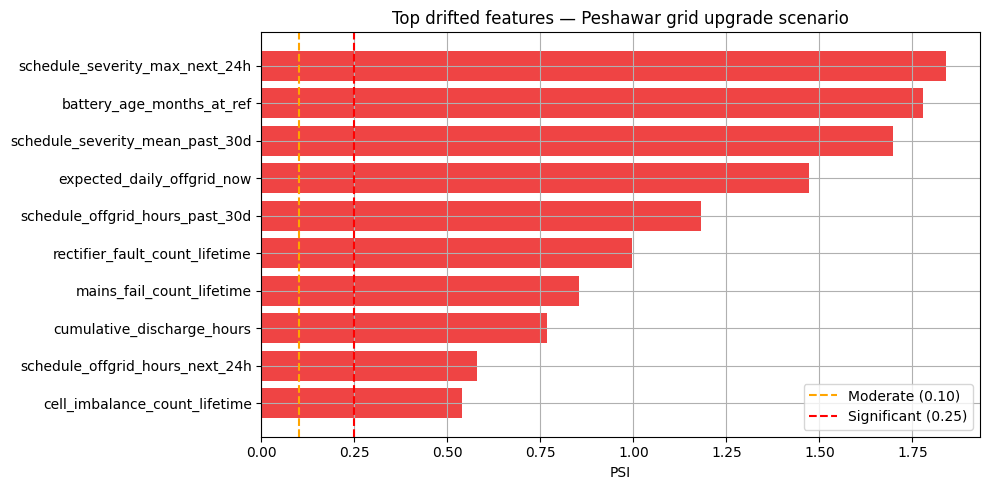

In [7]:
# Plot the top drifted features
fd = drift_report["feature_drift"]
drifted = fd[fd["drift_level"] != "STABLE"].head(10).iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#ef4444" if l == "SIGNIFICANT" else "#f59e0b"
          for l in drifted["drift_level"]]
ax.barh(drifted["feature"], drifted["psi"], color=colors)
ax.axvline(0.10, color="orange", linestyle="--", label="Moderate (0.10)")
ax.axvline(0.25, color="red", linestyle="--", label="Significant (0.25)")
ax.set_xlabel("PSI")
ax.set_title("Top drifted features — Peshawar grid upgrade scenario")
ax.legend()
plt.tight_layout()
plt.show()


## Step 6: what does the operator do?

This is where most ML systems stop ("alert fired, retrain the model") — and
where the system breaks subtly.

**The naive response: "drift detected → retrain on recent data → deploy."**

If we retrain on months 24-30 (post-upgrade), the model learns:
> "Peshawar sites have low alarm counts but still drain — therefore low alarm
> count means high risk in Peshawar."

This is **temporarily correct** (worn batteries still failing) but will be
**wrong in 3 months** once the batteries get replaced. The model will then
need to be retrained *again*.

**The real-world response:**
1. **Week 1:** Drift alert fires. Data scientist investigates. Discovers the
   grid upgrade. (This is **diagnosis**, not just detection.)
2. **Weeks 1-4:** Operator override — suppress or reduce Peshawar alerts
   manually. Log the override.
3. **Weeks 4-12:** Accumulate new ground-truth labels under the new regime.
4. **Week 12:** Retrain with:
   - All historical data (don't discard pre-upgrade — still teaches us about
     other regions)
   - A new feature: `is_post_upgrade` or `months_since_intervention`
   - Recency-weighted sampling so recent observations matter more
5. **Week 13:** CV the new model. Promote only if it beats the current
   champion on a shared held-out set (this is our `RetrainingFlow`).

The lesson: **drift monitoring is the detection layer; the response is
operational**, and the model improvements come from *causal feature engineering*,
not from frequent retraining.


## Takeaway

| | |
|--|--|
| **What we detected** | 10+ features with PSI > 0.25, prediction distribution shifted, retrain recommended |
| **What we'd be wrong about** | Peshawar sites flagged as *higher* risk when they're objectively safer |
| **The cost without monitoring** | Generators dispatched to safe Peshawar sites; other regions silently worsen unmonitored |
| **The deeper lesson** | A model that learns symptoms (LVD counts) instead of causes (outage frequency × battery age) is fragile to interventions |

This is why the system has:
- Reference profile **from training time** (not from production)
- **Per-region** AUC monitoring in CloudWatch (not just overall)
- Champion/challenger retraining on a **shared held-out set** (not just CV)
- Cold-start fallback to **regional priors** (catches the new-site failure mode)

See `src/battery_pdm/monitoring/drift.py` for the PSI implementation and
`scripts/simulate_drift.py` for the standalone version of this scenario.
